# Finance, Revisited, II.
## RENORMALISED VARIATIONS,
## ARITHMETIC,
## 2026.
####

In [62]:
# pip install numpy pandas matplotlib yfinance
#
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import yfinance as yf

# I. --- GRPLB

## I.A. - CORRELATION CALCULATIONS

### I.A.1. --- DIRECT

In [63]:
symbols = ["GUER", "PLAB"]

DATA = yf.download(symbols, start="2025-08-01")["Close"]
DN = DATA / DATA.iloc[0]

window = 23
spread = 11
t = 60

X, Y = DN.iloc[t : t + window, 0], DN.iloc[t + spread : t + window + spread, 1]
X, Y = X / X.iloc[0], Y / Y.iloc[0]

[*********************100%***********************]  2 of 2 completed


In [64]:
COEF = float(np.corrcoef(X, Y)[1][0])
dx, dy = np.array(X.pct_change().dropna()), np.array(Y.pct_change().dropna())
delta = (
    np.prod((1 + np.abs(dx)) * (1 + np.abs(dy))) ** (1 / len(dx)) - 1
)  # ad hoc upper bound error

In [65]:
_x, _y = np.array(X / X.iloc[0]), np.array(Y / Y.iloc[0])
_x = (_x - 1) * (_y[-1] - 1) / (_x[-1] - 1) + 1

e_absolute_ = np.abs(_x - _y)
e_absolute = np.prod(1 + e_absolute_) ** (1 / len(e_absolute_)) - 1

e_relative_ = np.abs(_x / _y - 1)
e_relative = np.prod(1 + e_relative_) ** (1 / len(e_relative_)) - 1

In [66]:
out_string = (
    f"Correlation Metrics:\nCorrelation: {100 * COEF:.1f}% +/- {100 * delta:.1f}%\n"
)
out_string += "Error Metrics:\n"
out_string += f"Absolute error: {100 * e_absolute:.1f} %\n"
out_string += f"Relative error: {100 * e_relative:.1f} %"
print(out_string)

Correlation Metrics:
Correlation: 96.3% +/- 12.5%
Error Metrics:
Absolute error: 4.8 %
Relative error: 4.2 %


### I.A.2. --- RELATIVE

In [67]:
start = "2025-01-01"
end = None

symbols = ["GUER", "PLAB"]

DATA = yf.download(symbols, start=start, end=end)["Close"]

spread_months = np.linspace(0, 1, 11)
spread_days = spread_months * 250 / 12
spread_days = spread_days.astype(int)

coefs = []
dates = []

for i in range(DN.shape[0] - spread_days[-1] - window):
    x = DN.iloc[i : i + window, 0]
    for spread in spread_days:
        y = DN.iloc[i + spread : i + window + spread, 1]
        coef = np.cov(x, y) / (np.std(x) * np.std(y))
        coef = float(coef[1][0])
        coefs.append(coef)

coefs = np.array(coefs)

mean_, median_, std_ = (
    float(np.mean(coefs)),
    float(np.median(coefs)),
    float(np.std(coefs)),
)

[*********************100%***********************]  2 of 2 completed


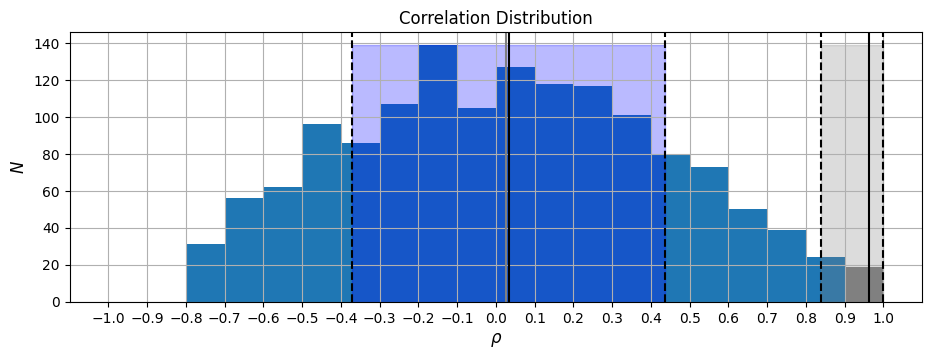

CORRELATION 
Measured: 96.3% +/- 12.5%
Mean: 3.3%
Median: 2.5%
Standard deviation: 40.5%
(Measured - Mean) / Sigma ~ 229.8 %
(Measured - Median) / Sigma ~ 231.7%
Relative frequency (approximate): 1.33%
Relative frequency (precise): 0.14%



In [68]:
x_min, x_max = -1, 1
n_bins = 21
bins = np.linspace(x_min, x_max, n_bins)
m_upper, m_lower = min(1, COEF + delta), max(-1, COEF - delta)
c_upper, c_lower = min(1, mean_ + std_), max(-1, mean_ - std_)
#
plt.figure(figsize=(11, 3.5))
x, y, z = plt.hist(coefs, bins=bins)
plt.title("Correlation Distribution", fontsize=12)
plt.ylabel("$N$", fontsize=12)
plt.xlabel("$\\rho$", fontsize=12)
plt.xticks(bins)
plt.grid()
#
plt.axvline(COEF, color="black")
plt.fill_betweenx((0, np.max(x)), m_lower, m_upper, color="gray", alpha=0.27)
plt.axvline(m_upper, color="k", linestyle="--")
plt.axvline(m_lower, color="k", linestyle="--")
#
plt.fill_betweenx((0, np.max(x)), c_lower, c_upper, color="blue", alpha=0.27)
plt.axvline(c_upper, color="k", linestyle="--")
plt.axvline(mean_, color="k")
plt.axvline(median_, color="gray")
plt.axvline(c_lower, color="k", linestyle="--")
z[-1].set_facecolor("gray")
plt.show()
# STATS
out_string = f"CORRELATION \nMeasured: {100 * COEF:.1f}% +/- {100 * delta:.1f}%\nMean: {100 * mean_:.1f}%\nMedian: {100 * median_:.1f}%\nStandard deviation: {100 * std_:.1f}%\n"
out_string += f"(Measured - Mean) / Sigma ~ {100 * (COEF - mean_) / std_:.1f} %\n"
out_string += f"(Measured - Median) / Sigma ~ {100 * (COEF - median_) / std_:.1f}%\n"
out_string += f"Relative frequency (approximate): {100 * x[-1] / len(coefs):.2f}%\n"
out_string += f"Relative frequency (precise): {100 * (1 - (COEF > coefs).sum() / len(coefs)):.2f}%\n"
print(out_string)

## I.B. --- INTERASIGNAL DEVIATIONS

In [69]:
# normalisations
X, Y = np.array(X), np.array(Y)
X = (X - 1) * (Y[-1] - 1) / (X[-1] - 1) + 1

# intrasignal deviations
DX_ = np.abs(X[1:] - X[:-1])
DY_ = np.abs(Y[1:] - Y[:-1])
D2_ = DX_**2 + DY_**2
D_ = D2_**0.5

# intramean
D = 0.5 * (np.mean(D_) + np.median(D_))
D2 = (np.mean(D2_) * np.median(D2_)) ** 0.5

# intersignal deviations
E_ = np.abs(X - Y)
E2_ = (X - Y) ** 2

# intermean
E = 0.5 * (np.mean(E_) + np.median(E_))
E2 = (np.mean(E2_) * np.median(E2_)) ** 0.5

# interasignal
intera = E - D
intera_relative = E / D - 1

intera_2 = E2 - D2
intera_2_relative = E2 / D2 - 1

In [70]:
# Intrasignal, Intersignal, interasignal aboslute, interasignal relative
out_string = "Basic Statistics\n\n"
out_string += f"Intrasignal: {D:.3e}\n"
out_string += f"Intersignal: {E:.3e}\n\n"
out_string += "Deviation Means:\n"
out_string += f"Interasignal absolute: {intera:.3e}\n"
out_string += f"Interasignal relative: {100 * intera_relative:.2f} %\n\n"
# Squared Intrasignal, Intersignal, interasignal aboslute, interasignal relative
out_string += f"Intrasignal squared: {D2:.3e}\n"
out_string += f"Intersignal squared: {E2:.3e}\n\n"
out_string += "Squared Deviation Means:\n"
out_string += f"Interasignal sqaured absolute: {intera_2:.3e}\n"
out_string += f"Interasignal squared relative: {100 * intera_2_relative:.2f} %\n"
print(out_string)

Basic Statistics

Intrasignal: 7.113e-02
Intersignal: 4.364e-02

Deviation Means:
Interasignal absolute: -2.748e-02
Interasignal relative: -38.64 %

Intrasignal squared: 7.716e-03
Intersignal squared: 2.626e-03

Squared Deviation Means:
Interasignal sqaured absolute: -5.090e-03
Interasignal squared relative: -65.97 %



# II. --- GSPCC

## II.A. --- CORRELATION CALCULATIONS

### II.A.1. --- DIRECT

#### II.A.1.a. --- CONSTRUCTED INDEX: C.I. 

In [71]:
# PRELIMINARIES
N = 42

symbols = [
    "BA",
    "INTC",
    "LPLA",
    "MU",
]

start = "2024-06-28"
end = "2024-10-01"

S = yf.download(symbols, start=start, end=end)["Close"]
DATA = S / S.iloc[0]

MEAN_N = DATA.mean(axis=1)
X = MEAN_N.iloc[:N]

IRR = (MEAN_N.loc["2024-08-07"] / MEAN_N.loc["2024-07-10"]) ** (
    251 / (MEAN_N.index.get_loc("2024-08-07") - MEAN_N.index.get_loc("2024-07-10"))
) - 1
IRR = float(IRR)

[*********************100%***********************]  4 of 4 completed


#### II.A.1.c. --- GSPC

In [72]:
idx = "^GSPC"
start = "2025-02-01"
end = "2025-05-01"
IDX = yf.download(idx, start=start, end=end)["Close"]
IDX_N = IDX / IDX.iloc[0]
Y = IDX_N["^GSPC"].iloc[:N]

[*********************100%***********************]  1 of 1 completed


In [73]:
x_, y_ = np.array(X), np.array(Y)
x_ = (x_ - 1) * (y_[-1] - 1) / (x_[-1] - 1) + 1

COEF = np.corrcoef(x_, y_)[1][0]
dx, dy = np.array(X.pct_change().dropna()), np.array(Y.pct_change().dropna())
delta = (
    np.prod((1 + np.abs(dx)) * (1 + np.abs(dy))) ** (1 / len(dx)) - 1
)  # ad hoc upper bound error
print(f"\nCOEF: {100 * COEF:.1f}% +/- {100 * delta:.1f}%")  # better options available


COEF: 95.4% +/- 2.8%


In [74]:
e_absolute_ = np.abs(x_ - y_)
e_absolute = np.prod(1 + e_absolute_) ** (1 / len(e_absolute_)) - 1

e_relative_ = np.abs(x_ / y_ - 1)
e_relative = np.prod(1 + e_relative_) ** (1 / len(e_relative_)) - 1

#### II.A.1.c. --- DIRECT METRICS CORRELATION

In [75]:
out_string = (
    f"Correlation Metrics:\nCorrelation: {100 * COEF:.1f}% +/- {100 * delta:.1f}%\n"
)
out_string += "Error Metrics:\n"
out_string += f"Absolute error: {100 * e_absolute:.2f} %\n"
out_string += f"Relative error: {100 * e_relative:.2f} %"
print(out_string)

Correlation Metrics:
Correlation: 95.4% +/- 2.8%
Error Metrics:
Absolute error: 0.88 %
Relative error: 0.89 %


### II.A.2. --- RELATIVE 

In [76]:
start = "2024-01-01"
end = None

symbols = ["BA", "INTC", "LPLA", "MU"]

DATA = yf.download(symbols, start=start, end=end)["Close"]

idx = "^GSPC"
IDX = yf.download(idx, start=start, end=end)["Close"]
IDX_N = IDX / IDX.iloc[0]

spread_months = np.linspace(5, 10, 101)
spread_days = spread_months * 250 / 12
spread_days = spread_days.astype(int)

window = N

coefs = []
dates = []

for i in range(IDX_N.shape[0] - spread_days[-1] - window):
    x = (DATA.iloc[i : i + window] / DATA.iloc[i]).mean(axis=1)
    for spread in spread_days:
        y = (
            IDX_N["^GSPC"].iloc[i + spread : i + spread + window]
            / IDX_N["^GSPC"].iloc[i + spread]
        )
        coef = np.corrcoef(x, y)
        coef = float(coef[1][0])
        coefs.append(coef)

coefs = np.array(coefs)

mean_, median_, std_ = (
    float(np.mean(coefs)),
    float(np.median(coefs)),
    float(np.std(coefs)),
)

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


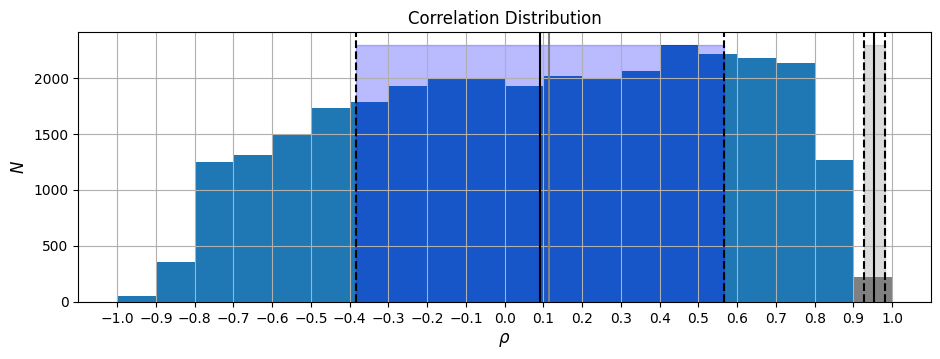

CORRELATION 
Measured: 95.4% +/- 2.8%
Mean: 9.1%
Median: 11.5%
Standard deviation: 47.5%
(Measured - Mean) / Sigma ~ 181.7 %
(Measured - Median) / Sigma ~ 176.6%
Relative frequency (approximate): 0.67%
Relative frequency (precise): 0.02%



In [77]:
x_min, x_max = -1, 1
n_bins = 21
bins = np.linspace(x_min, x_max, n_bins)
m_upper, m_lower = min(1, COEF + delta), max(-1, COEF - delta)
c_upper, c_lower = min(1, mean_ + std_), max(-1, mean_ - std_)
#
plt.figure(figsize=(11, 3.5))
x, y, z = plt.hist(coefs, bins=bins)
plt.title("Correlation Distribution", fontsize=12)
plt.ylabel("$N$", fontsize=12)
plt.xlabel("$\\rho$", fontsize=12)
plt.xticks(bins)
plt.grid()
#
plt.axvline(COEF, color="black")
plt.fill_betweenx((0, np.max(x)), m_lower, m_upper, color="gray", alpha=0.27)
plt.axvline(m_upper, color="k", linestyle="--")
plt.axvline(m_lower, color="k", linestyle="--")
#
plt.fill_betweenx((0, np.max(x)), c_lower, c_upper, color="blue", alpha=0.27)
plt.axvline(c_upper, color="k", linestyle="--")
plt.axvline(mean_, color="k")
plt.axvline(median_, color="gray")
plt.axvline(c_lower, color="k", linestyle="--")
z[-1].set_facecolor("gray")
plt.show()
# STATS
out_string = f"CORRELATION \nMeasured: {100 * COEF:.1f}% +/- {100 * delta:.1f}%\nMean: {100 * mean_:.1f}%\nMedian: {100 * median_:.1f}%\nStandard deviation: {100 * std_:.1f}%\n"
out_string += f"(Measured - Mean) / Sigma ~ {100 * (COEF - mean_) / std_:.1f} %\n"
out_string += f"(Measured - Median) / Sigma ~ {100 * (COEF - median_) / std_:.1f}%\n"
out_string += f"Relative frequency (approximate): {100 * x[-1] / len(coefs):.2f}%\n"
out_string += f"Relative frequency (precise): {100 * (1 - (COEF > coefs).sum() / len(coefs)):.2f}%\n"
print(out_string)

## B. - INTERASIGNAL DEVIATIONS

In [78]:
# normalisations
X, Y = np.array(X), np.array(Y)
X = (X - 1) * (Y[-1] - 1) / (X[-1] - 1) + 1

# intrasignal deviations
DX_ = np.abs(X[1:] - X[:-1])
DY_ = np.abs(Y[1:] - Y[:-1])
D2_ = DX_**2 + DY_**2
D_ = D2_**0.5

# intramean
D = 0.5 * (np.mean(D_) + np.median(D_))
D2 = (np.mean(D2_) * np.median(D2_)) ** 0.5

# intersignal deviations
E_ = np.abs(X - Y)
E2_ = (X - Y) ** 2

# intermean
E = 0.5 * (np.mean(E_) + np.median(E_))
E2 = (np.mean(E2_) * np.median(E2_)) ** 0.5

# interasignal
intera = E - D
intera_relative = E / D - 1

intera_2 = E2 - D2
intera_2_relative = E2 / D2 - 1

In [79]:
# Intrasignal, Intersignal, interasignal aboslute, interasignal relative
out_string = "Basic Statistics\n\n"
out_string += f"Intrasignal: {D:.3e}\n"
out_string += f"Intersignal: {E:.3e}\n\n"
out_string += "Deviation Means:\n"
out_string += f"Interasignal absolute: {intera:.3e}\n"
out_string += f"Interasignal relative: {100 * intera_relative:.2f} %\n\n"
# Squared Intrasignal, Intersignal, interasignal aboslute, interasignal relative
out_string += f"Intrasignal squared: {D2:.3e}\n"
out_string += f"Intersignal squared: {E2:.3e}\n\n"
out_string += "Squared Deviation Means:\n"
out_string += f"Interasignal sqaured absolute: {intera_2:.3e}\n"
out_string += f"Interasignal squared relative: {100 * intera_2_relative:.2f} %\n"
print(out_string)

Basic Statistics

Intrasignal: 9.234e-03
Intersignal: 7.658e-03

Deviation Means:
Interasignal absolute: -1.576e-03
Interasignal relative: -17.07 %

Intrasignal squared: 1.030e-04
Intersignal squared: 7.480e-05

Squared Deviation Means:
Interasignal sqaured absolute: -2.818e-05
Interasignal squared relative: -27.36 %



# ---------

#### Finance, Revisited, II.
#### 2026

# ---------